# Import essential data analysis and visualization libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load training data and display its shape and first few rows

In [2]:
traindataframe = pd.read_csv('train.csv')
print("Train data shape :",traindataframe.shape)

print("Train data head:")
print(traindataframe.head())


Train data shape : (630000, 21)
Train data head:
   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3                     0.87          13.32     61.57      1357.33   
4                     0.96          20.22     91.11      1538.20   

   Sunlight_Hours  ...  Crop_Type Crop_Growth_Stage  Season Irrigation_Type  \
0            5.90  ...  Sugarcane            Sowing    Zaid            Drip   
1            6.98  ...      W

# Display statistical summary and remove missing values and duplicates from training data

In [3]:
traindataframe.describe()
traindataframe = traindataframe.dropna()
traindataframe = traindataframe.drop_duplicates()



# Display information about data types and non-null counts for each column

In [4]:
traindataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

# Remove the ID column as it's not useful for model training

In [5]:
traindataframe = traindataframe.drop(columns=['id'])

# Visualize box plots and remove outliers using IQR method for numerical columns

box plot for int and outliers


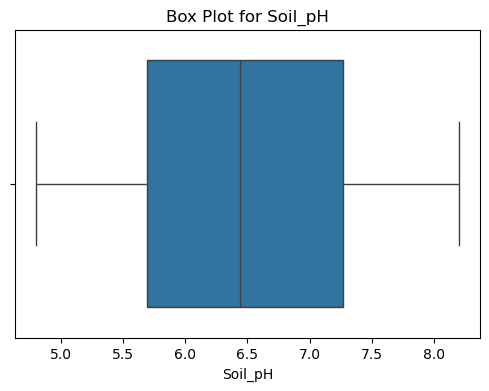

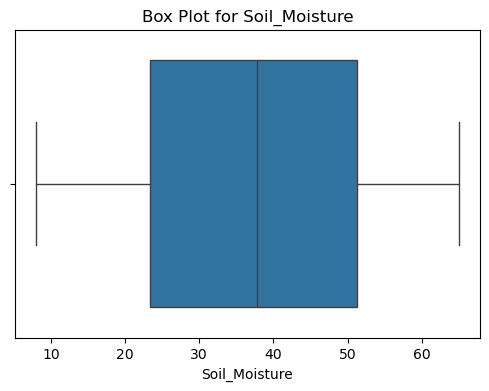

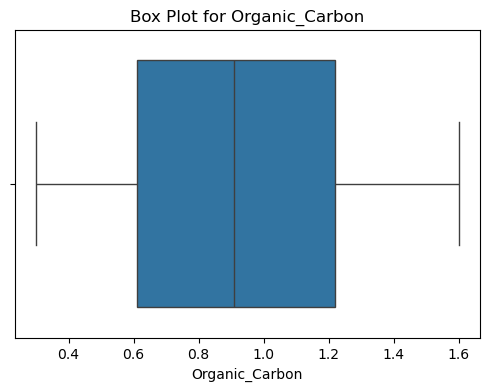

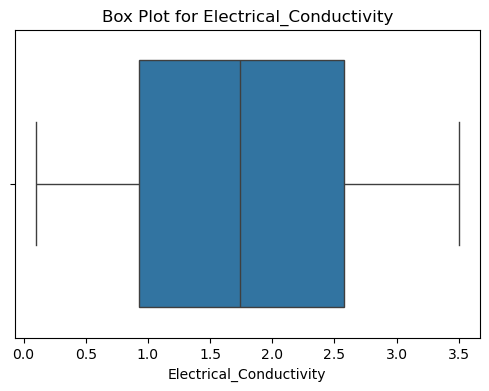

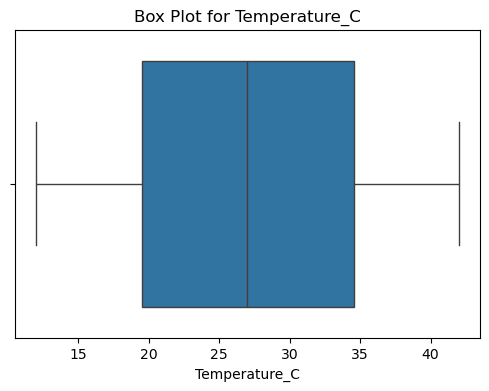

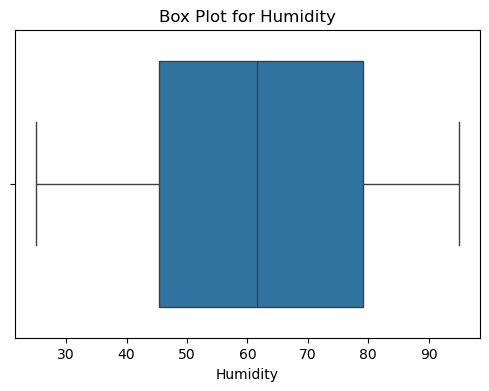

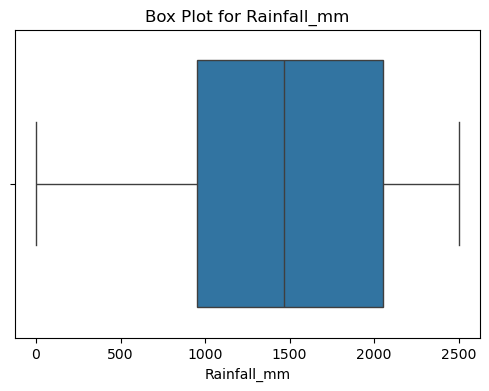

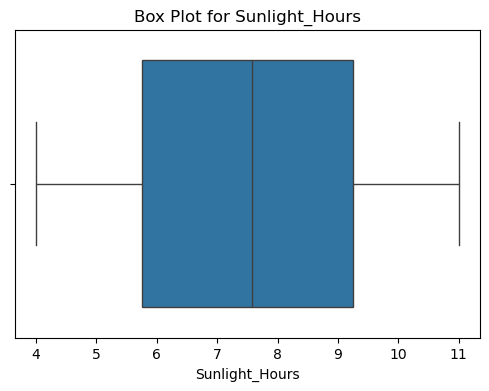

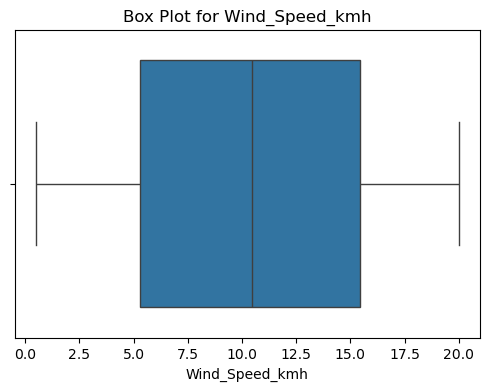

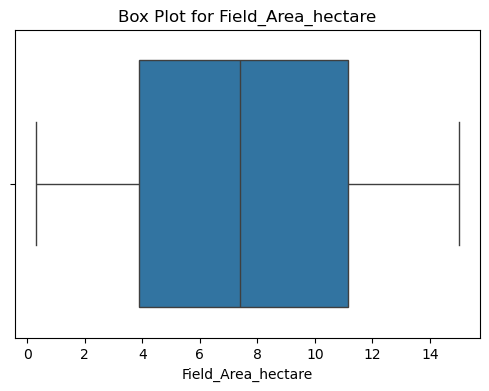

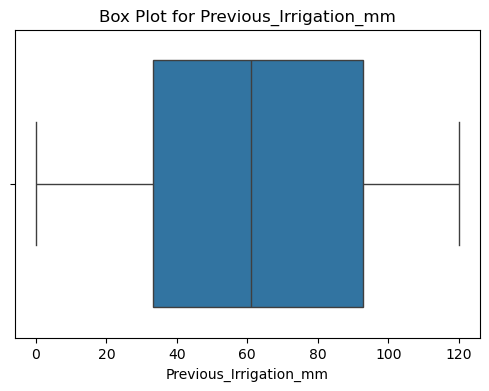

In [6]:
print("box plot for int and outliers")
for column in traindataframe.columns:
    if traindataframe[column].dtype in ['int64', 'float64']:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=traindataframe[column])
        plt.title(f'Box Plot for {column}')
        plt.show()
        q1 = traindataframe[column].quantile(0.25)
        q3 = traindataframe[column].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5*iqr
        upper_bound = q3 + 1.5*iqr
        traindataframe = traindataframe[(traindataframe[column] >= lower_bound) & (traindataframe[column] <= upper_bound)]

# Import preprocessing tools and initialize encoders and scalers for data transformation

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
OneHot = OneHotEncoder()
label = LabelEncoder()
scaler = StandardScaler()

# Identify and display unique values for all categorical columns

In [8]:
object_columns = traindataframe.select_dtypes(include=['object']).columns
num_columns = traindataframe.select_dtypes(include=['int64', 'float64']).columns
for column in object_columns:
    print(column,":",traindataframe[column].unique())

Soil_Type : ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type : ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage : ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season : ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type : ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source : ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used : ['No' 'Yes']
Region : ['East' 'South' 'North' 'West' 'Central']
Irrigation_Need : ['Low' 'Medium' 'High']


# Encode categorical features using label encoding and mapping dictionaries

In [9]:
irrigation_map = {'Low': 0, 'Medium': 1, 'High': 2}

traindataframe["Mulching_Used"] = label.fit_transform(traindataframe["Mulching_Used"])
traindataframe["Irrigation_Need"] = traindataframe["Irrigation_Need"].map(irrigation_map)

print("Mulching_Used",":",traindataframe["Mulching_Used"].unique())
print("Irrigation_Need",":",traindataframe["Irrigation_Need"].unique())

Mulching_Used : [0 1]
Irrigation_Need : [0 1 2]


# Apply one-hot encoding to remaining categorical columns and combine with original data

In [10]:
label_encode = ["Mulching_Used" ,"Irrigation_Need"]

for column in traindataframe.columns:
    if traindataframe[column].dtype == 'object' and column not in label_encode:
        encoded_array = OneHot.fit_transform(traindataframe[[column]]).toarray()
        new_cols = OneHot.get_feature_names_out([column])
        temp_df = pd.DataFrame(encoded_array, columns=new_cols, index=traindataframe.index)
        traindataframe = pd.concat([traindataframe, temp_df], axis=1)
        traindataframe.drop(column, axis=1, inplace=True)

# Display the encoded data structure and information after transformations

In [11]:

print ("Data after encoding:")
print(traindataframe.head())
print(traindataframe.info())

Data after encoding:
   Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0     4.92          32.58            1.01                     3.05   
1     7.08          56.61            0.44                     2.00   
2     5.69          27.71            0.81                     2.83   
3     5.65          13.32            1.33                     0.87   
4     7.96          59.14            0.38                     0.96   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0          15.01     50.61       725.99            5.90           16.79   
1          22.92     67.86       985.66            6.98            3.39   
2          26.97     92.22      2201.70            6.05            3.85   
3          13.32     61.57      1357.33            9.12            2.31   
4          20.22     91.11      1538.20            6.95           13.94   

   Field_Area_hectare  ...  Irrigation_Type_Sprinkler  \
0                0.82  ...                        

# Calculate and visualize feature correlations with the target variable

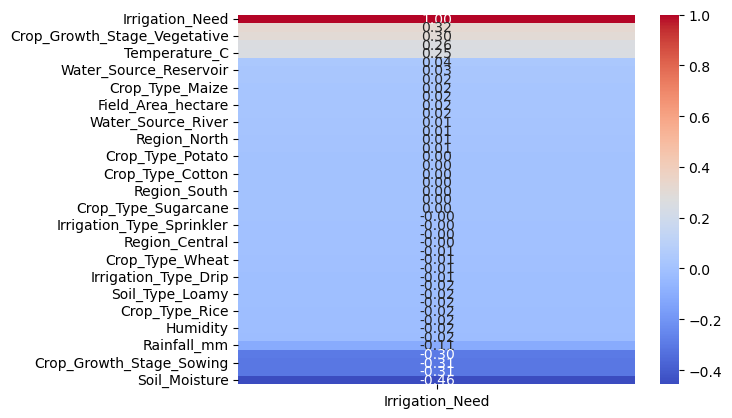

Correlation Values:                               Irrigation_Need
Irrigation_Need                      1.000000
Soil_Moisture                        0.455482
Crop_Growth_Stage_Flowering          0.321888
Crop_Growth_Stage_Harvest            0.312770
Crop_Growth_Stage_Sowing             0.312283
Crop_Growth_Stage_Vegetative         0.302851
Mulching_Used                        0.300043
Wind_Speed_kmh                       0.258170
Temperature_C                        0.252867
Rainfall_mm                          0.111478
Irrigation_Type_Canal                0.035745
Water_Source_Reservoir               0.025116
Water_Source_Groundwater             0.024094
Season_Kharif                        0.022350
Humidity                             0.021870
Crop_Type_Maize                      0.020588
Irrigation_Type_Rainfed              0.020134
Previous_Irrigation_mm               0.019637
Crop_Type_Rice                       0.018281
Field_Area_hectare                   0.017699
Season_Rabi   

In [12]:
corr = traindataframe.corr()
labeled_corr = corr[['Irrigation_Need']].sort_values(by='Irrigation_Need', ascending=False)
sns.heatmap(labeled_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()
abs_labeled_corr = corr[['Irrigation_Need']].abs().sort_values(by='Irrigation_Need', ascending=False)
print("Correlation Values:", abs_labeled_corr)


# Remove features with low correlation to target variable using defined thresholds

In [13]:
threshold_num = 0.05
threshold_object = 0.01
delet_columns = []
for column in traindataframe.columns:
    if column in num_columns:
        if abs_labeled_corr.loc[column, 'Irrigation_Need'] < threshold_num:
            delet_columns.append(column)
    else:
        if abs_labeled_corr.loc[column, 'Irrigation_Need'] < threshold_object:
            delet_columns.append(column)
print ("Columns to delete:", len(delet_columns))
print("Columns to delete:", delet_columns)
traindataframe.drop(delet_columns, axis=1, inplace=True)

Columns to delete: 20
Columns to delete: ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Humidity', 'Sunlight_Hours', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Soil_Type_Clay', 'Soil_Type_Silt', 'Crop_Type_Cotton', 'Crop_Type_Potato', 'Crop_Type_Sugarcane', 'Crop_Type_Wheat', 'Season_Zaid', 'Irrigation_Type_Sprinkler', 'Region_Central', 'Region_East', 'Region_North', 'Region_South', 'Region_West']


# Recalculate and visualize correlation matrix after feature removal

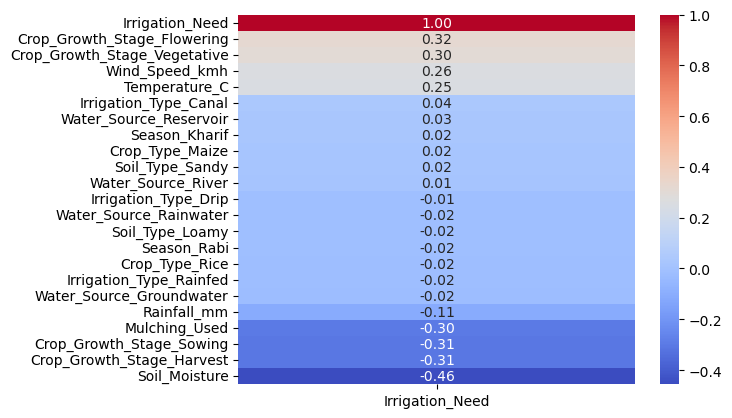

Correlation Values:                               Irrigation_Need
Irrigation_Need                      1.000000
Soil_Moisture                        0.455482
Crop_Growth_Stage_Flowering          0.321888
Crop_Growth_Stage_Harvest            0.312770
Crop_Growth_Stage_Sowing             0.312283
Crop_Growth_Stage_Vegetative         0.302851
Mulching_Used                        0.300043
Wind_Speed_kmh                       0.258170
Temperature_C                        0.252867
Rainfall_mm                          0.111478
Irrigation_Type_Canal                0.035745
Water_Source_Reservoir               0.025116
Water_Source_Groundwater             0.024094
Season_Kharif                        0.022350
Crop_Type_Maize                      0.020588
Irrigation_Type_Rainfed              0.020134
Crop_Type_Rice                       0.018281
Season_Rabi                          0.017339
Soil_Type_Sandy                      0.017301
Soil_Type_Loamy                      0.017037
Water_Source_R

In [14]:
corr = traindataframe.corr()
labeled_corr = corr[['Irrigation_Need']].sort_values(by='Irrigation_Need', ascending=False)
sns.heatmap(labeled_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()
abs_labeled_corr = corr[['Irrigation_Need']].abs().sort_values(by='Irrigation_Need', ascending=False)
print("Correlation Values:", abs_labeled_corr)


# Display comprehensive correlation heatmap of all features

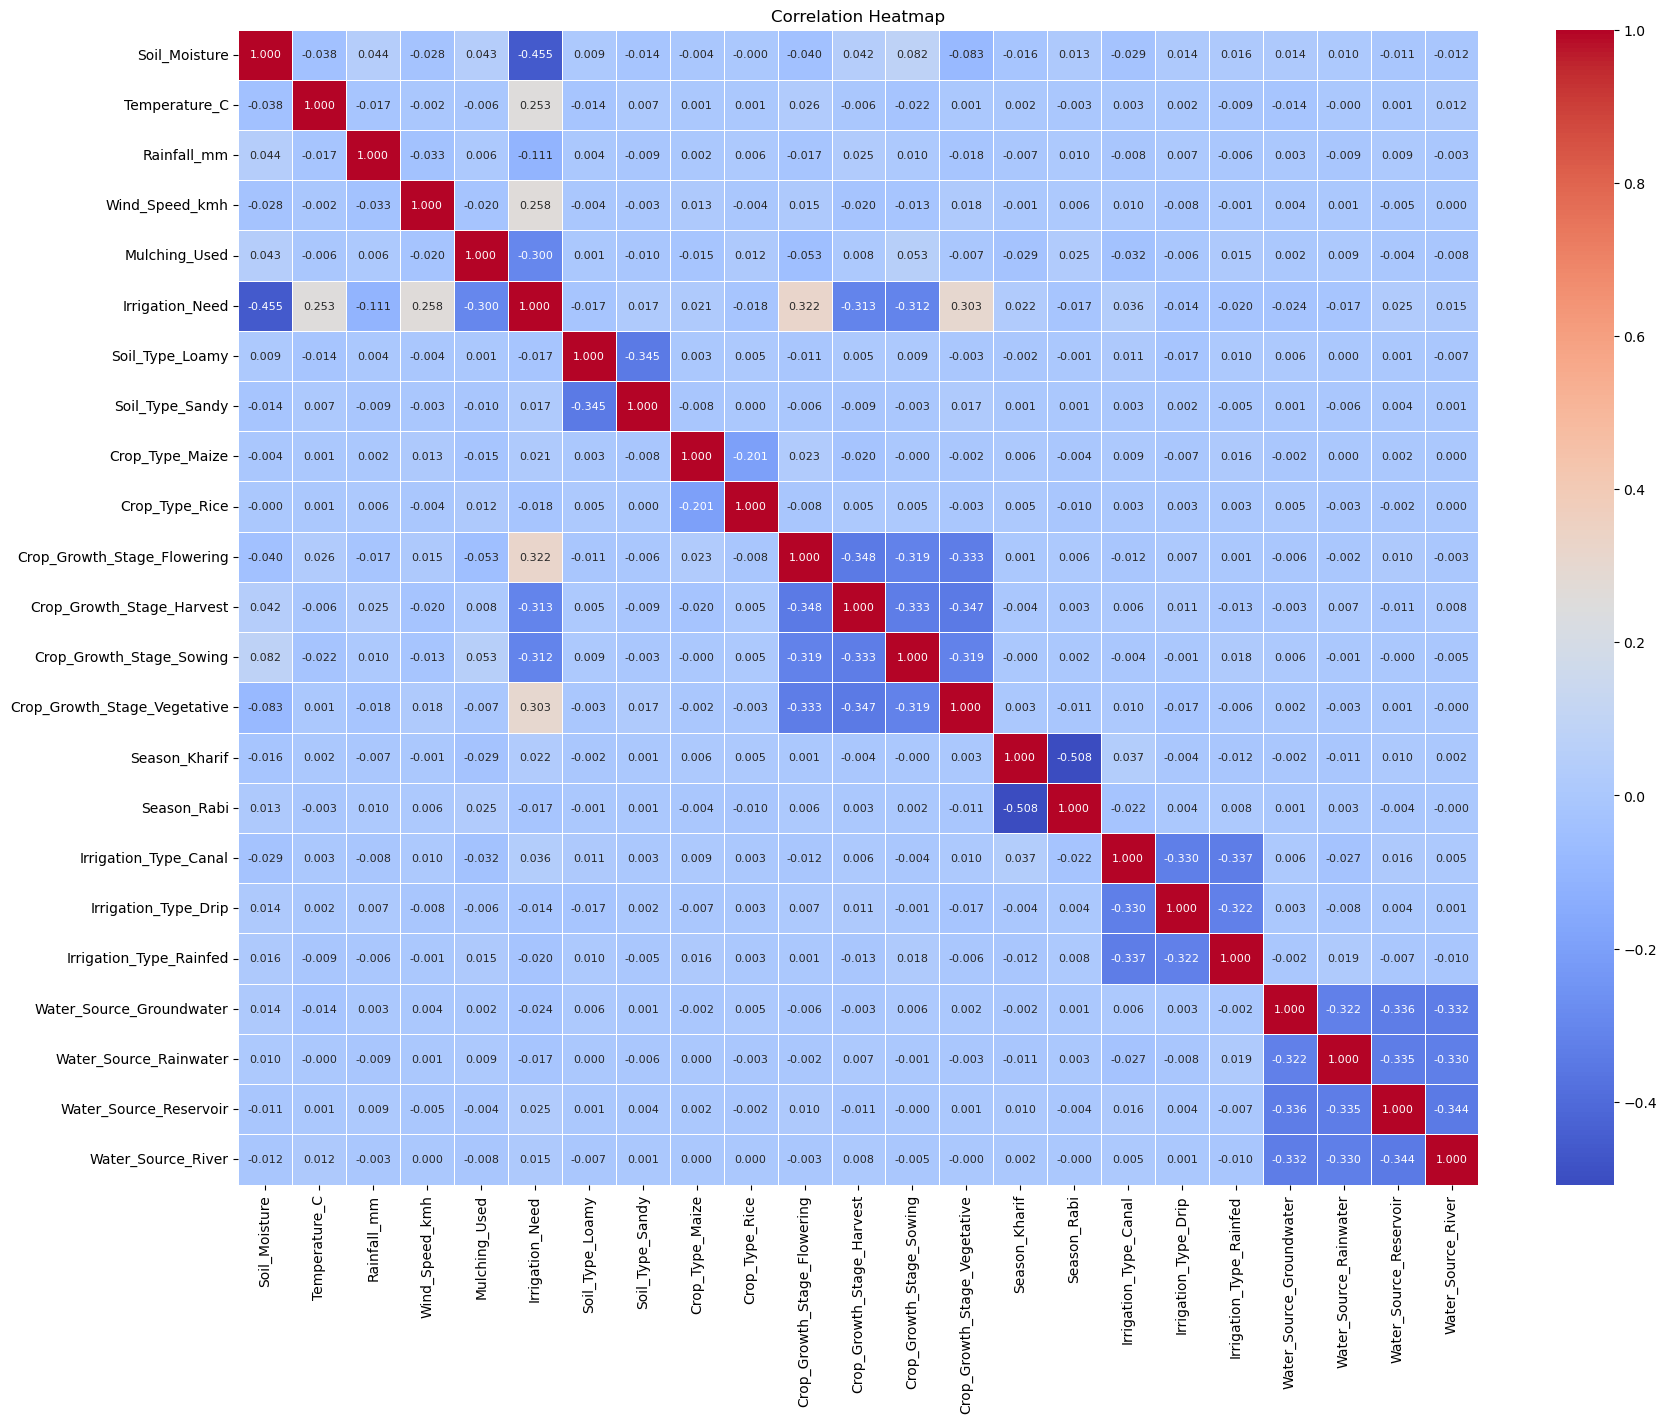

In [15]:
plt.figure(figsize=(20, 15))
sns.heatmap(traindataframe.corr(),
            annot=True, cmap='coolwarm', fmt='.3f',
            annot_kws={"size": 8},
            linewidths=0.5
            )
plt.title("Correlation Heatmap")
plt.show()

# Visualize the distribution of the target variable (Irrigation_Need)

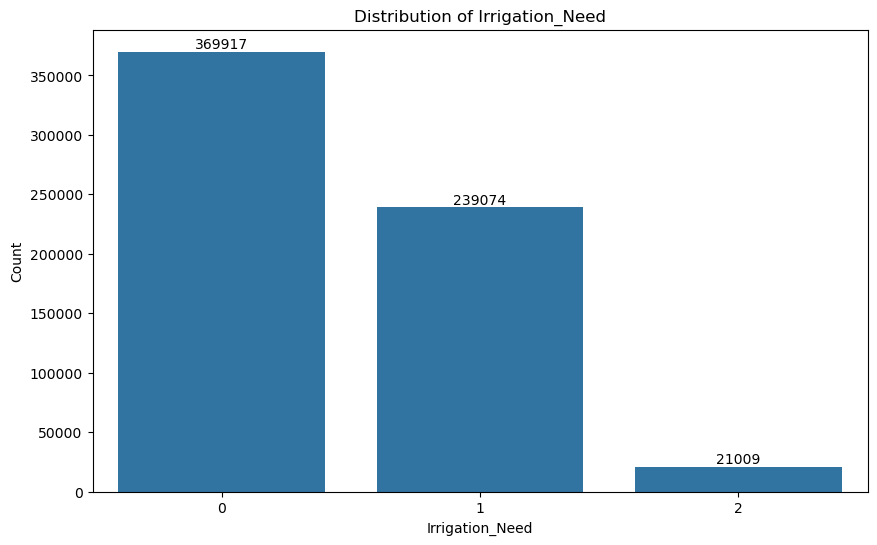

In [16]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Irrigation_Need', data=traindataframe)
ax.bar_label(ax.containers[0])
plt.title('Distribution of Irrigation_Need')
plt.xlabel('Irrigation_Need')
plt.ylabel('Count')
plt.show()

# Split data into train/test sets and apply standard scaling transformation

In [17]:
train , test = train_test_split(traindataframe, test_size=0.2, random_state=42,stratify= traindataframe['Irrigation_Need'])

X_train = train.drop(columns=['Irrigation_Need'])
y_train = train['Irrigation_Need']

X_test = test.drop(columns=['Irrigation_Need'])
y_test = test['Irrigation_Need']

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Train logistic regression model and evaluate its accuracy on test data

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


Logic_model = LogisticRegression(max_iter=1000, verbose=1,class_weight='balanced',random_state=42,)
Logic_model.fit(X_train_scaled, y_train)

logic_y_pred = Logic_model.predict(X_test_scaled)
logic_accuracy = accuracy_score(y_test, logic_y_pred)

print(f"Accuracy: {logic_accuracy:.4f}")

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           69     M =           10
 This problem is unconstrained.

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.09861D+00    |proj g|=  2.66254D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   69     21     24      1     0     0   6.083D-05   3.584D-01
  F =  0.35842031048932554     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
Accuracy: 0.8412


# Display confusion matrix for logistic regression predictions

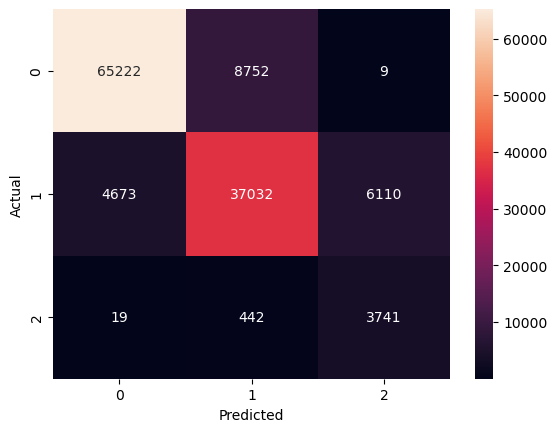

In [19]:
cm = confusion_matrix(y_test, logic_y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Train random forest classifier with optimized hyperparameters and evaluate

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42, 
    verbose=1,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

rf_y_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_y_pred)

print(f"Accuracy: {rf_accuracy:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.6s


Accuracy: 0.9842


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    7.7s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.1s finished


# Display confusion matrix for random forest predictions

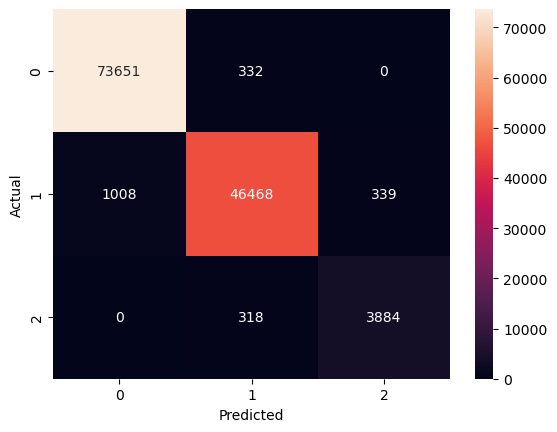

In [21]:
cm = confusion_matrix(y_test, rf_y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Compare training and testing accuracy for random forest model

In [22]:
train_pred = rf_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {rf_accuracy:.4f}")

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s


Train Accuracy: 0.9850
Test Accuracy: 0.9842


[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.5s finished


# Train XGBoost classifier with tuned hyperparameters and calculate test accuracy

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

XG_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    class_weight='balanced',
    random_state=42, 
    verbose=1,
    n_jobs=-1
)

XG_model.fit(X_train_scaled, y_train)

XG_y_pred = XG_model.predict(X_test_scaled)
XG_accuracy = accuracy_score(y_test, XG_y_pred)

print(f"Accuracy: {XG_accuracy:.4f}")

/home/hebo/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [06:10:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9843


# Display confusion matrix for XGBoost predictions

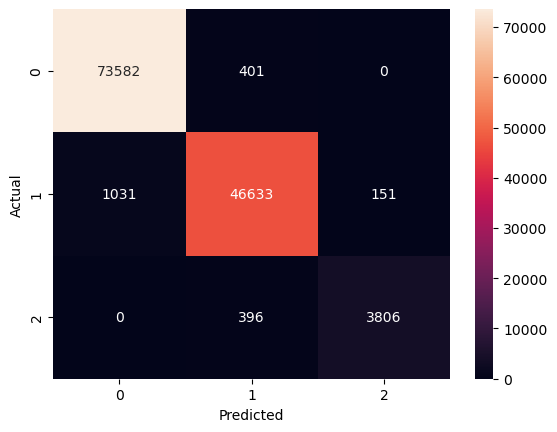

In [24]:
cm = confusion_matrix(y_test, XG_y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Compare training and testing accuracy for XGBoost model

In [25]:
train_pred = XG_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {XG_accuracy:.4f}")

Train Accuracy: 0.9846
Test Accuracy: 0.9843


# Save all trained models & scaler & columns to pickle files for later use

In [26]:
import joblib
joblib.dump(Logic_model, 'LR_model.pkl')
joblib.dump(rf_model, 'Rf_model.pkl')
joblib.dump(XG_model, 'XG_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
training_columns = X_train.columns.tolist()
joblib.dump(training_columns, 'training_columns.pkl')

['training_columns.pkl']

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=50,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=5,
    validation_fraction=0.1,
    verbose=1,
)

nn_model.fit(X_train_scaled, y_train)

nn_train_pred = nn_model.predict(X_train_scaled)
nn_test_pred = nn_model.predict(X_test_scaled)

nn_train_acc = accuracy_score(y_train, nn_train_pred)
nn_test_acc = accuracy_score(y_test, nn_test_pred)

print("Neural Network Train Accuracy:", nn_train_acc)
print("Neural Network Test Accuracy:", nn_test_acc)
print(classification_report(y_test, nn_test_pred))

joblib.dump(nn_model, 'NN_model.pkl')

Iteration 1, loss = 0.19206992
Validation score: 0.953750
Iteration 2, loss = 0.11859224
Validation score: 0.965595
Iteration 3, loss = 0.10044730
Validation score: 0.971845
Iteration 4, loss = 0.09150782
Validation score: 0.973532
Iteration 5, loss = 0.08667002
Validation score: 0.972877
Iteration 6, loss = 0.08328628
Validation score: 0.977063
Iteration 7, loss = 0.08119704
Validation score: 0.976111
Iteration 8, loss = 0.07917361
Validation score: 0.977599
Iteration 9, loss = 0.07765814
Validation score: 0.978492
Iteration 10, loss = 0.07634816
Validation score: 0.977956
Iteration 11, loss = 0.07542535
Validation score: 0.978075
Iteration 12, loss = 0.07464222
Validation score: 0.977321
Iteration 13, loss = 0.07413573
Validation score: 0.978750
Iteration 14, loss = 0.07330838
Validation score: 0.978849
Iteration 15, loss = 0.07267992
Validation score: 0.979385
Iteration 16, loss = 0.07230010
Validation score: 0.978849
Iteration 17, loss = 0.07170234
Validation score: 0.978988
Iterat

['NN_model.pkl']